# Random 
# Missing indicator
# Automatic selection

Random imputer
1. Filling by random number (select random number from the data) :  Easy to use, Variance is almost same.
2. Memory heavy for deployment, as we need to store original training data of that variable to fill the upcoming NA observations. 
3. Good at Linear models as it doest not distort

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\train (1).csv', usecols=['Age', 'Fare', 'Survived'])

In [3]:
print(df.isnull().mean()*100)

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64


In [4]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=.2)

In [6]:
x_train['Age_imputed'] = x_train['Age']     # copying values of age
x_test['Age_imputed'] = x_test['Age']

In [ ]:
# x_train['Age_imputed'][x_train['Age_imputed'].isnull()]   
#gives null values, total 148

In [ ]:
# x_train['Age'].dropna().sample(1).values
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
# x_train['Age'].isnull().sum()   # will give the number of NA values
# removing NA, sample extrainct 148 values 

array([31. , 23. , 32. , 36. , 54. , 30. ,  1. , 45. ,  1. , 17. , 54. ,
       35. , 28.5, 23. , 34. , 18. , 51. ,  5. , 27. , 26. , 33. , 21. ,
       48. , 20. , 29. , 16. , 14. , 25. , 47. , 21. , 32. ,  4. , 50. ,
       32. , 15. , 39. , 27. , 24. , 16. , 30. , 15. ,  9. , 45. , 28. ,
       48. , 24. , 18. , 39. , 25. , 19. , 26. , 23. , 29. , 25. , 36. ,
        3. , 41. , 64. , 17. , 22. , 31. , 40. , 35. , 52. , 40. , 32. ,
       35. , 54. , 28. , 31. , 40. , 16. ,  9. , 46. , 17. , 32. , 63. ,
       27. , 22. , 30. , 26. , 26. , 47. , 32. , 39. , 16. ,  1. , 24. ,
       35. , 31. , 29. , 40. , 23. , 25. , 22. , 17. , 33. , 24.5, 58. ,
       47. , 17. , 21. , 42. , 55. , 44. , 59. , 28. , 18. , 62. , 30. ,
       18. , 23. , 52. , 16. , 36. , 36. , 39. , 17. , 45. , 40.5, 18. ,
       25. , 17. , 26. , 49. , 14. ,  4. , 47. , 30. , 15. , 42. , 26. ,
       50. , 30. , 48. , 50. , 36. , 37. , 61. , 11. , 50. ,  9. , 35. ,
        9. ])

In [ ]:
x_train.loc[                        # df.loc[row_condition, column_name]
    x_train['Age_imputed'].isnull(),'Age_imputed'] = x_train['Age'].dropna().sample(
        x_train['Age'].isnull().sum(),
        random_state=42
    ).values

x_test.loc[
    x_test['Age_imputed'].isnull(),
    'Age_imputed'] = x_train['Age'].dropna().sample(
        x_test['Age'].isnull().sum(),
        random_state=42
    ).values


In [ ]:
# x_train
x_train.isnull().mean()*100
# age imputed has no missing vlaues

Age            20.224719
Fare            0.000000
Age_imputed     0.000000
dtype: float64

C:\Users\rajku\AppData\Local\Temp\ipykernel_22276\3925229177.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original',hist=False)
C:\Users\rajku\AppData\Local\Temp\ipykernel_22276\3925229177.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[

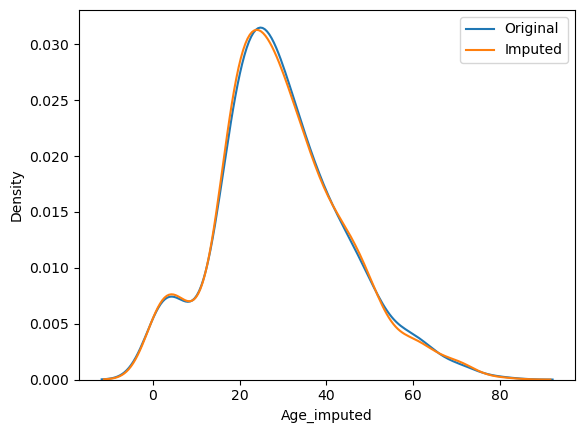

In [45]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [46]:
print("Original variance", x_train['Age'].var())
print("Random imputaion variance", x_train['Age_imputed'].var())

Original variance 210.70657190401576
Random imputaion variance 211.09512488009435


In [49]:
x_train[['Fare','Age', 'Age_imputed']].var()

Fare           2297.809775
Age             210.706572
Age_imputed     211.095125
dtype: float64

In [ ]:
# there should be same random value of Age_Imputed for given Fare value
# sample_value = x_train['Age'].dropna().sample(1, random_state= int(oservation['Fare']))